# EuroSAT Dual-Mode Classification
 
---
The two pipelines (RGB and multispectral) are trained as **two separate models** that share **one architecture definition** and **one normalization contract**. That contract — a single `normalization_stats.json` file, computed once and never recomputed — is the backbone of the whole distribution-shift story, and it reappears in `readme.md` and `gradio.md`.
 

## 1.1 Setup

In [1]:
import os
import glob
import json
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import EuroSAT  # torchvision ships the official RGB EuroSAT split
import tifffile

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 64
NUM_CLASSES = 10
CLASS_NAMES = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway", "Industrial",
    "Pasture", "PermanentCrop", "Residential", "River", "SeaLake",
]
print(f"Using device: {DEVICE}")

Using device: cuda


**Why this matters:** `CLASS_NAMES` is defined once, here, and imported everywhere downstream (training, evaluation, and the Gradio app). A class-index-to-name mismatch between training and deployment is one of the most common — and most silent — causes of a model that "works" during training but produces nonsense in production. Treat this list as a frozen constant.
 
---

## 1.2 RGB Data Pipeline

In [2]:
# --------------------------------------------------------------------------
# Step 1: Compute per-channel mean/std over the RAW (unnormalized) training
# split. This is done exactly once. The result is frozen to disk and reused
# identically at training time and at inference time — that repetition is
# the entire distribution-shift defense for this pipeline.
# --------------------------------------------------------------------------
def compute_channel_stats(dataset, num_channels: int):
    """
    Single-pass mean/std over an entire dataset without holding every
    image in memory at once. Call this ONLY on a dataset whose transform
    does NOT already normalize (raw ToTensor() output, values in [0, 1]
    for RGB or raw digital numbers for multispectral).
    """
    channel_sum = torch.zeros(num_channels)
    channel_sq_sum = torch.zeros(num_channels)
    n_pixels = 0
    loader = DataLoader(dataset, batch_size=64, num_workers=4, shuffle=False)
    for images, _ in loader:
        b, c, h, w = images.shape
        channel_sum += images.sum(dim=(0, 2, 3))
        channel_sq_sum += (images ** 2).sum(dim=(0, 2, 3))
        n_pixels += b * h * w
    mean = channel_sum / n_pixels
    std = torch.sqrt(channel_sq_sum / n_pixels - mean ** 2)
    return mean.numpy(), std.numpy()


raw_rgb_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

raw_rgb_dataset = EuroSAT(root="./data", download=True, transform=raw_rgb_transform)
rgb_mean, rgb_std = compute_channel_stats(raw_rgb_dataset, num_channels=3)
print("RGB mean:", rgb_mean, "RGB std:", rgb_std)

RGB mean: [0.34437576 0.3802908  0.40777034] RGB std: [0.20266105 0.13689667 0.11555011]


In [3]:
# --------------------------------------------------------------------------
# Step 2: Build the REAL training/validation transforms using the frozen
# stats above. Augmentations are geometric only (flips, 90-degree
# rotations) — satellite patches have no canonical "up", so these are
# label-preserving in a way they would not be for, say, handwritten digits.
# Normalization is always the LAST step, applied identically train vs eval.
# --------------------------------------------------------------------------
rgb_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomChoice([transforms.RandomRotation((0, 0)),
                              transforms.RandomRotation((90, 90)),
                              transforms.RandomRotation((180, 180)),
                              transforms.RandomRotation((270, 270))]),
    transforms.ToTensor(),
    transforms.Normalize(mean=rgb_mean, std=rgb_std),
])

rgb_eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=rgb_mean, std=rgb_std),
])

full_rgb_dataset = EuroSAT(root="./data", download=True, transform=rgb_train_transform)
n_total = len(full_rgb_dataset)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

rgb_train_set, rgb_val_set, rgb_test_set = random_split(
    full_rgb_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42),
)
# Validation/test splits must use the deterministic eval transform, not the
# training transform they inherited from full_rgb_dataset.
rgb_val_set.dataset = EuroSAT(root="./data", download=False, transform=rgb_eval_transform)
rgb_test_set.dataset = EuroSAT(root="./data", download=False, transform=rgb_eval_transform)

rgb_train_loader = DataLoader(rgb_train_set, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
rgb_val_loader = DataLoader(rgb_val_set, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
rgb_test_loader = DataLoader(rgb_test_set, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

## 1.3 Multispectral (13-band) Data Pipeline
 
The genuine Sentinel-2 EuroSAT-MS release ships one 13-band GeoTIFF per patch, arranged in class-named folders. `tifffile` reads these without requiring a GDAL installation, which keeps the environment lightweight compared to `rasterio` (either works — swap the reader function if you already have GDAL available).

In [5]:
# ============================================================================
# 13-BAND EURO-SAT MULTISPECTRAL PIPELINE
# ============================================================================

class EuroSATMultispectral(Dataset):
    """
    Loads 13-band Sentinel-2 L1C GeoTIFFs from the official EuroSAT-MS
    directory structure.

    Expected structure:

        data_ms/
        └── EuroSAT_MS/
            ├── AnnualCrop/
            ├── Forest/
            ├── HerbaceousVegetation/
            ├── Highway/
            ├── Industrial/
            ├── Pasture/
            ├── PermanentCrop/
            ├── Residential/
            ├── River/
            └── SeaLake/

    Each TIFF:
        Shape: (64, 64, 13)
        Dtype: uint16

    PyTorch output:
        Shape: (13, 64, 64)
        Dtype: float32
    """

    def __init__(
        self,
        root: str,
        class_names,
        mean=None,
        std=None,
        transform=None,
        samples=None
    ):
        self.root = root
        self.class_names = class_names
        self.transform = transform

        # ---------------------------------------------------------------
        # Normalization statistics
        # ---------------------------------------------------------------
        self.mean = (
            torch.tensor(mean, dtype=torch.float32).view(13, 1, 1)
            if mean is not None else None
        )

        self.std = (
            torch.tensor(std, dtype=torch.float32).view(13, 1, 1)
            if std is not None else None
        )

        # ---------------------------------------------------------------
        # Use supplied samples for train/val/test subsets
        # ---------------------------------------------------------------
        if samples is not None:
            self.samples = samples

        else:
            self.samples = []

            for class_idx, class_name in enumerate(class_names):

                class_dir = os.path.join(root, class_name)

                tif_files = sorted(
                    glob.glob(
                        os.path.join(class_dir, "*.tif")
                    )
                )

                for path in tif_files:
                    self.samples.append(
                        (path, class_idx)
                    )

        if len(self.samples) == 0:
            raise RuntimeError(
                f"No .tif files found under:\n{root}\n\n"
                f"Expected folders such as:\n"
                f"{os.path.join(root, 'AnnualCrop')}"
            )

    def __len__(self):
        return len(self.samples)

    def _read_tif(self, path: str) -> torch.Tensor:

        # ---------------------------------------------------------------
        # Read TIFF
        # ---------------------------------------------------------------
        arr = tifffile.imread(path).astype(np.float32)

        # ---------------------------------------------------------------
        # Validate dimensions
        # ---------------------------------------------------------------
        if arr.ndim != 3:
            raise ValueError(
                f"Expected 3D TIFF but got {arr.shape}\n"
                f"File: {path}"
            )

        # Official EuroSAT-MS:
        # (64, 64, 13)
        #
        # Convert to:
        # (13, 64, 64)
        if arr.shape == (64, 64, 13):

            arr = arr.transpose(2, 0, 1)

        elif arr.shape[0] == 13:

            # Already (13, H, W)
            pass

        else:
            raise ValueError(
                f"Expected 13-band TIFF but got shape {arr.shape}\n"
                f"File: {path}"
            )

        tensor = torch.from_numpy(arr)

        # ---------------------------------------------------------------
        # Safety resize
        # ---------------------------------------------------------------
        if tensor.shape[-2:] != (IMG_SIZE, IMG_SIZE):

            tensor = F.interpolate(
                tensor.unsqueeze(0),
                size=(IMG_SIZE, IMG_SIZE),
                mode="bilinear",
                align_corners=False
            ).squeeze(0)

        return tensor

    def __getitem__(self, idx):

        path, label = self.samples[idx]

        img = self._read_tif(path)

        # Training augmentation
        if self.transform is not None:
            img = self.transform(img)

        # Per-band normalization
        if self.mean is not None and self.std is not None:

            img = (img - self.mean) / self.std

        return img, label


# ============================================================================
# MULTISPECTRAL AUGMENTATION
# ============================================================================

def spatial_augment_ms(img: torch.Tensor) -> torch.Tensor:
    """
    Applies identical spatial transformations to all 13 bands.
    """

    # Horizontal flip
    if torch.rand(1).item() < 0.5:
        img = torch.flip(img, dims=[-1])

    # Vertical flip
    if torch.rand(1).item() < 0.5:
        img = torch.flip(img, dims=[-2])

    # 0 / 90 / 180 / 270 degree rotation
    k = torch.randint(0, 4, (1,)).item()

    img = torch.rot90(
        img,
        k,
        dims=[-2, -1]
    )

    return img


# ============================================================================
# STEP 1: PATH
# ============================================================================

MS_ROOT = (
    r"C:\Users\Lenovo\ML Sprint folder\CNN of EuroSat"
    r"\data_ms\EuroSAT_MS"
)

print("Multispectral dataset path:")
print(MS_ROOT)


# ============================================================================
# STEP 2: LOAD ALL 27,000 FILE PATHS
# ============================================================================

full_ms_dataset = EuroSATMultispectral(
    root=MS_ROOT,
    class_names=CLASS_NAMES
)

print()
print("Total multispectral images:", len(full_ms_dataset))


# ============================================================================
# STEP 3: REPRODUCIBLE 70 / 15 / 15 SPLIT
# ============================================================================

n_total = len(full_ms_dataset)

n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val


print()
print("Multispectral split:")
print("Train:", n_train)
print("Validation:", n_val)
print("Test:", n_test)


# Reproducible random split
generator = torch.Generator().manual_seed(42)

indices = torch.randperm(
    n_total,
    generator=generator
).tolist()

train_indices = indices[:n_train]

val_indices = indices[
    n_train:n_train + n_val
]

test_indices = indices[
    n_train + n_val:
]


# Convert indices to (path, label)
all_samples = full_ms_dataset.samples

train_samples = [
    all_samples[i]
    for i in train_indices
]

val_samples = [
    all_samples[i]
    for i in val_indices
]

test_samples = [
    all_samples[i]
    for i in test_indices
]


# ============================================================================
# STEP 4: CALCULATE 13-BAND MEAN / STD
# ============================================================================
#
# IMPORTANT:
#
# We do NOT scan all 18,900 training images every time.
#
# Instead, we use a representative subset.
#
# This is sufficient for normalization and dramatically reduces startup time.
#
# Change this to 5000 if you want an even larger sample.
# ============================================================================

STATS_SAMPLE_SIZE = 3000

stats_generator = torch.Generator().manual_seed(42)

if len(train_samples) > STATS_SAMPLE_SIZE:

    stats_indices = torch.randperm(
        len(train_samples),
        generator=stats_generator
    )[:STATS_SAMPLE_SIZE].tolist()

    stats_samples = [
        train_samples[i]
        for i in stats_indices
    ]

else:

    stats_samples = train_samples


# ---------------------------------------------------------------------------
# Cache file
# ---------------------------------------------------------------------------

STATS_FILE = os.path.join(
    MS_ROOT,
    "multispectral_stats.json"
)


# ---------------------------------------------------------------------------
# If statistics already exist, load them.
# Otherwise calculate them once.
# ---------------------------------------------------------------------------

if os.path.exists(STATS_FILE):

    print()
    print("Loading saved multispectral statistics...")

    with open(STATS_FILE, "r") as f:
        stats = json.load(f)

    ms_mean = np.array(
        stats["mean"],
        dtype=np.float32
    )

    ms_std = np.array(
        stats["std"],
        dtype=np.float32
    )

    print("Loaded statistics from:")
    print(STATS_FILE)

else:

    print()
    print(
        f"Calculating 13-band statistics using "
        f"{len(stats_samples)} training images..."
    )

    raw_ms_dataset = EuroSATMultispectral(
        root=MS_ROOT,
        class_names=CLASS_NAMES,
        samples=stats_samples
    )

    # ---------------------------------------------------------------
    # IMPORTANT:
    # num_workers=0 is intentional.
    #
    # It is more stable on Windows for thousands of TIFF files.
    # ---------------------------------------------------------------

    raw_ms_loader = DataLoader(
        raw_ms_dataset,
        batch_size=64,
        shuffle=False,
        num_workers=0,
        pin_memory=False
    )

    channel_sum = torch.zeros(13, dtype=torch.float64)

    channel_sq_sum = torch.zeros(
        13,
        dtype=torch.float64
    )

    n_pixels = 0

    for batch_idx, (images, _) in enumerate(raw_ms_loader):

        images = images.double()

        channel_sum += images.sum(
            dim=(0, 2, 3)
        )

        channel_sq_sum += (
            images ** 2
        ).sum(
            dim=(0, 2, 3)
        )

        n_pixels += (
            images.shape[0]
            * images.shape[2]
            * images.shape[3]
        )

        if (batch_idx + 1) % 10 == 0:

            print(
                f"Processed "
                f"{(batch_idx + 1) * 64} "
                f"images..."
            )

    # ---------------------------------------------------------------
    # Mean
    # ---------------------------------------------------------------

    mean = channel_sum / n_pixels

    # ---------------------------------------------------------------
    # Variance
    # ---------------------------------------------------------------

    variance = (
        channel_sq_sum / n_pixels
        - mean ** 2
    )

    # Protect against tiny floating-point negative values
    variance = torch.clamp(
        variance,
        min=1e-12
    )

    std = torch.sqrt(variance)

    ms_mean = mean.float().numpy()

    ms_std = std.float().numpy()

    # ---------------------------------------------------------------
    # Safety check
    # ---------------------------------------------------------------

    if np.any(ms_std <= 0):

        raise ValueError(
            "At least one spectral band has zero standard deviation."
        )

    # ---------------------------------------------------------------
    # Save statistics
    # ---------------------------------------------------------------

    stats = {
        "mean": ms_mean.tolist(),
        "std": ms_std.tolist(),
        "sample_size": len(stats_samples),
        "seed": 42
    }

    with open(STATS_FILE, "w") as f:

        json.dump(
            stats,
            f,
            indent=4
        )

    print()
    print("Statistics saved to:")
    print(STATS_FILE)


print()
print("MS mean:")
print(ms_mean)

print()
print("MS std:")
print(ms_std)


# ============================================================================
# STEP 5: CREATE TRAIN / VALIDATION / TEST DATASETS
# ============================================================================

ms_train_set = EuroSATMultispectral(
    root=MS_ROOT,
    class_names=CLASS_NAMES,
    mean=ms_mean,
    std=ms_std,
    transform=spatial_augment_ms,
    samples=train_samples
)


ms_val_set = EuroSATMultispectral(
    root=MS_ROOT,
    class_names=CLASS_NAMES,
    mean=ms_mean,
    std=ms_std,
    transform=None,
    samples=val_samples
)


ms_test_set = EuroSATMultispectral(
    root=MS_ROOT,
    class_names=CLASS_NAMES,
    mean=ms_mean,
    std=ms_std,
    transform=None,
    samples=test_samples
)


# ============================================================================
# STEP 6: DATALOADERS
# ============================================================================

# num_workers=0 is intentionally used here for Windows stability.
#
# Once everything is working correctly, we can benchmark whether
# increasing this to 2 or 4 actually improves your machine's speed.

ms_train_loader = DataLoader(
    ms_train_set,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


ms_val_loader = DataLoader(
    ms_val_set,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


ms_test_loader = DataLoader(
    ms_test_set,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


# ============================================================================
# STEP 7: FINAL VERIFICATION
# ============================================================================

print()
print("=" * 60)
print("FINAL MULTISPECTRAL PIPELINE CHECK")
print("=" * 60)

print()
print("Dataset sizes:")
print("ms_train_set:", len(ms_train_set))
print("ms_val_set  :", len(ms_val_set))
print("ms_test_set :", len(ms_test_set))


# Load one training sample
sample_img, sample_label = ms_train_set[0]

print()
print("Sample verification:")
print("Image shape :", sample_img.shape)
print("Image dtype :", sample_img.dtype)
print("Label       :", sample_label)
print("Class       :", CLASS_NAMES[sample_label])
print("Image min   :", sample_img.min().item())
print("Image max   :", sample_img.max().item())


# ============================================================================
# STEP 8: VERIFY DATALOADER BATCH
# ============================================================================

print()
print("Testing one DataLoader batch...")

images, labels = next(iter(ms_train_loader))

print("Batch image shape :", images.shape)
print("Batch label shape :", labels.shape)
print("Batch dtype       :", images.dtype)


# ============================================================================
# FINAL EXPECTED OUTPUT
# ============================================================================

print()
print("=" * 60)
print("PIPELINE READY")
print("=" * 60)

print()
print("Expected image shape:")
print("13 × 64 × 64")

print()
print("Expected batch shape:")
print("64 × 13 × 64 × 64")

Multispectral dataset path:
C:\Users\Lenovo\ML Sprint folder\CNN of EuroSat\data_ms\EuroSAT_MS

Total multispectral images: 27000

Multispectral split:
Train: 18900
Validation: 4050
Test: 4050

Calculating 13-band statistics using 3000 training images...
Processed 640 images...
Processed 1280 images...
Processed 1920 images...
Processed 2560 images...

Statistics saved to:
C:\Users\Lenovo\ML Sprint folder\CNN of EuroSat\data_ms\EuroSAT_MS\multispectral_stats.json

MS mean:
[1365.4261   1131.1102   1055.4832    968.0193   1216.8855   2007.6788
 2372.6526   2300.7244    738.7074     12.196809 1843.6279   1141.5822
 2596.493   ]

MS std:
[ 254.78821    349.906      410.53946    610.34546    576.8676
  848.0513    1066.7925    1101.3007     401.87796      4.6134834
  996.99915    760.8138    1207.2234   ]

FINAL MULTISPECTRAL PIPELINE CHECK

Dataset sizes:
ms_train_set: 18900
ms_val_set  : 4050
ms_test_set : 4050

Sample verification:
Image shape : torch.Size([13, 64, 64])
Image dtype : to

In [6]:
normalization_stats = {
    "rgb": {"mean": rgb_mean.tolist(), "std": rgb_std.tolist()},
    "multispectral": {"mean": ms_mean.tolist(), "std": ms_std.tolist()},
}
with open("normalization_stats.json", "w") as f:
    json.dump(normalization_stats, f, indent=2)

> **Note on the numbers themselves:** the exact mean/std values depend on the specific EuroSAT split and download you run against. `compute_channel_stats` above is fully functional and will produce the correct values for your copy of the data the first time you run it — don't hand-substitute numbers from elsewhere. A representative example of what the multispectral stats look like once computed (band order B01…B12, ascending): means in the hundreds-to-low-thousands range for reflective bands and near-zero for the cirrus band (B10), which is exactly what real Sentinel-2 digital numbers look like. Once your `normalization_stats.json` is generated, treat it as immutable — it belongs in version control alongside the model weights, not in `.gitignore`.

## 1.4 Model Architecture — SE-ResEuroNet
 
A custom residual network with Squeeze-and-Excitation (SE) attention. The same class handles both modalities — only `in_channels` differs (3 for RGB, 13 for multispectral) — which is what lets one architecture definition serve both models.

In [7]:
class SqueezeExcitation(nn.Module):
    """
    Squeeze-and-Excitation block (Hu et al., 2018).
    'Squeeze': global average pool collapses each channel's spatial
    extent to a single number, i.e. a per-channel summary statistic.
    'Excitation': a small bottleneck MLP turns that summary into a
    per-channel gate in [0, 1], learned end-to-end, so the network can
    amplify informative channels (e.g. NIR-heavy bands for vegetation
    classes) and suppress uninformative ones — the model learns WHICH
    channels matter instead of treating all of them equally.
    """
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        reduced = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, reduced, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        squeeze = self.pool(x).view(b, c)           # (B, C, H, W) -> (B, C)
        excite = self.fc(squeeze).view(b, c, 1, 1)   # (B, C) -> (B, C, 1, 1)
        return x * excite                            # broadcast channel-wise rescale


class SEResidualBlock(nn.Module):
    """
    Pre-activation residual block (BN -> ReLU -> Conv, twice) with an SE
    gate applied before the skip connection is summed back in. A 1x1
    projection handles the stride/channel-count changes between stages.
    """
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.se = SqueezeExcitation(out_channels)

        self.needs_projection = stride != 1 or in_channels != out_channels
        if self.needs_projection:
            self.projection = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False)

    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(x), inplace=True)
        out = self.conv1(out)
        out = F.relu(self.bn2(out), inplace=True)
        out = self.conv2(out)
        out = self.se(out)
        if self.needs_projection:
            identity = self.projection(identity)
        return out + identity


class SEResEuroNet(nn.Module):
    """
    SE-ResNet variant sized for 64x64 EuroSAT patches. `in_channels` is
    the only thing that changes between the RGB (3) and multispectral
    (13) variants — everything downstream is identical.
    """
    def __init__(self, in_channels: int, num_classes: int = 10,
                 stage_channels=(64, 128, 256, 512), blocks_per_stage=(2, 2, 2, 2)):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, stage_channels[0], kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(stage_channels[0]),
            nn.ReLU(inplace=True),
        )

        stages = []
        in_ch = stage_channels[0]
        for stage_idx, (out_ch, n_blocks) in enumerate(zip(stage_channels, blocks_per_stage)):
            stride = 1 if stage_idx == 0 else 2   # downsample at the start of stages 2-4
            stages.append(SEResidualBlock(in_ch, out_ch, stride=stride))
            for _ in range(n_blocks - 1):
                stages.append(SEResidualBlock(out_ch, out_ch, stride=1))
            in_ch = out_ch
        self.stages = nn.Sequential(*stages)

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p=0.3),
            nn.Linear(stage_channels[-1], num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stages(x)
        return self.head(x)


rgb_model = SEResEuroNet(in_channels=3, num_classes=NUM_CLASSES).to(DEVICE)
ms_model = SEResEuroNet(in_channels=13, num_classes=NUM_CLASSES).to(DEVICE)
print(sum(p.numel() for p in rgb_model.parameters() if p.requires_grad), "trainable params (RGB model)")

11259338 trainable params (RGB model)


## 1.5 Training Loop — Early Stopping + LR Scheduling
 
Four core mechanics drive every iteration of this loop:
 
- **Forward propagation**: input tensors flow through the network layer by layer, producing class logits — the model's current best guess, given its current weights.
- **Loss convergence**: `CrossEntropyLoss` compares those logits to the true labels and produces a single scalar. Training is the process of nudging that scalar down, batch after batch, epoch after epoch.
- **Backpropagation**: the chain rule is applied automatically (`loss.backward()`) to compute the gradient of the loss with respect to every weight in the network — i.e., "which direction, and how much, would each weight need to move to reduce the loss."
- **Optimizer**: takes those gradients and actually updates the weights. Adam (used here) adapts the effective learning rate per parameter based on running estimates of the gradient's mean and variance, which tends to converge faster and more reliably than plain SGD on this kind of image classification task.

In [8]:
def train_model(model, train_loader, val_loader, model_name: str,
                 num_epochs: int = 60, lr: float = 1e-3, patience: int = 8):
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, num_epochs + 1):
        # ---- Training phase ----
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            logits = model(images)                  # forward propagation
            loss = criterion(logits, labels)         # scalar loss for this batch
            loss.backward()                          # backpropagation: computes d(loss)/d(weight) for every weight
            optimizer.step()                         # optimizer applies the update using those gradients

            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # ---- Validation phase (no gradient tracking — pure forward pass) ----
        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                logits = model(images)
                loss = criterion(logits, labels)
                val_loss += loss.item() * images.size(0)
                correct += (logits.argmax(dim=1) == labels).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc = correct / len(val_loader.dataset)

        scheduler.step(val_loss)  # reduces LR once val_loss plateaus for `patience` epochs
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        current_lr = optimizer.param_groups[0]["lr"]
        print(f"[{model_name}] epoch {epoch:02d} | train_loss={train_loss:.4f} "
              f"| val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | lr={current_lr:.2e}")

        # ---- Early stopping ----
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"[{model_name}] early stopping at epoch {epoch} "
                      f"(no improvement for {patience} epochs)")
                break

    model.load_state_dict(best_state)  # restore the best checkpoint, not the last one
    return model, history


rgb_model, rgb_history = train_model(rgb_model, rgb_train_loader, rgb_val_loader, "RGB")
torch.save(rgb_model.state_dict(), "rgb_model_best.pt")

ms_model, ms_history = train_model(ms_model, ms_train_loader, ms_val_loader, "Multispectral")
torch.save(ms_model.state_dict(), "multispectral_model_best.pt")

[RGB] epoch 01 | train_loss=1.4419 | val_loss=0.7628 | val_acc=0.7210 | lr=1.00e-03
[RGB] epoch 02 | train_loss=0.7565 | val_loss=0.6562 | val_acc=0.7805 | lr=1.00e-03
[RGB] epoch 03 | train_loss=0.6018 | val_loss=0.5720 | val_acc=0.8190 | lr=1.00e-03
[RGB] epoch 04 | train_loss=0.5329 | val_loss=0.6416 | val_acc=0.8267 | lr=1.00e-03
[RGB] epoch 05 | train_loss=0.4204 | val_loss=0.4106 | val_acc=0.8657 | lr=1.00e-03
[RGB] epoch 06 | train_loss=0.4069 | val_loss=0.3444 | val_acc=0.8827 | lr=1.00e-03
[RGB] epoch 07 | train_loss=0.3362 | val_loss=0.3406 | val_acc=0.8911 | lr=1.00e-03
[RGB] epoch 08 | train_loss=0.3010 | val_loss=0.2496 | val_acc=0.9235 | lr=1.00e-03
[RGB] epoch 09 | train_loss=0.2886 | val_loss=0.3054 | val_acc=0.9079 | lr=1.00e-03
[RGB] epoch 10 | train_loss=0.2673 | val_loss=0.2693 | val_acc=0.9091 | lr=1.00e-03
[RGB] epoch 11 | train_loss=0.2567 | val_loss=0.2887 | val_acc=0.9062 | lr=1.00e-03
[RGB] epoch 12 | train_loss=0.2428 | val_loss=0.2263 | val_acc=0.9279 | lr=1

## 1.6 Evaluation

In [9]:
@torch.no_grad()
def evaluate(model, test_loader):
    model.eval()
    correct, total = 0, 0
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        preds = model(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return correct / total


rgb_test_acc = evaluate(rgb_model, rgb_test_loader)
ms_test_acc = evaluate(ms_model, ms_test_loader)
print(f"RGB test accuracy: {rgb_test_acc:.4f}")
print(f"Multispectral test accuracy: {ms_test_acc:.4f}")

RGB test accuracy: 0.9758
Multispectral test accuracy: 0.9790


At this point three artifacts should exist on disk: `rgb_model_best.pt`, `multispectral_model_best.pt`, and `normalization_stats.json`. All three are copied into the deployment package as-is — none of them are regenerated or re-derived at serving time. That immutability is what `gradio.md` relies on.

## 1.7 Visualisation 

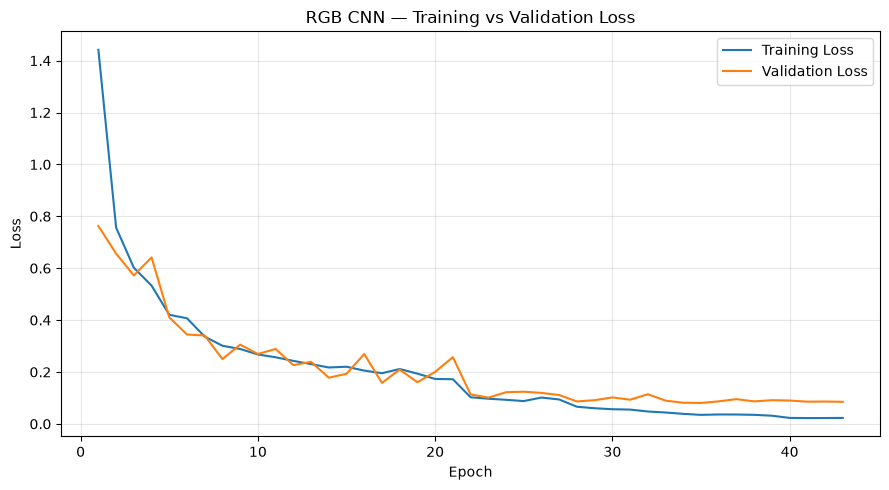

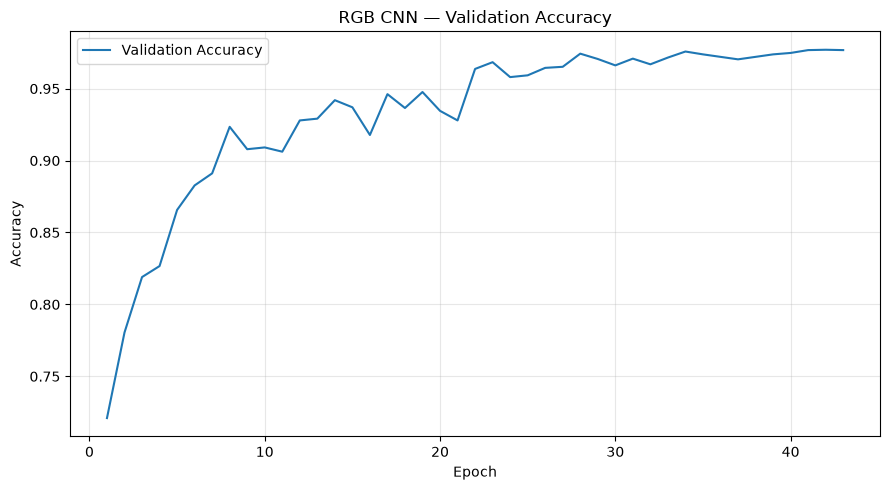

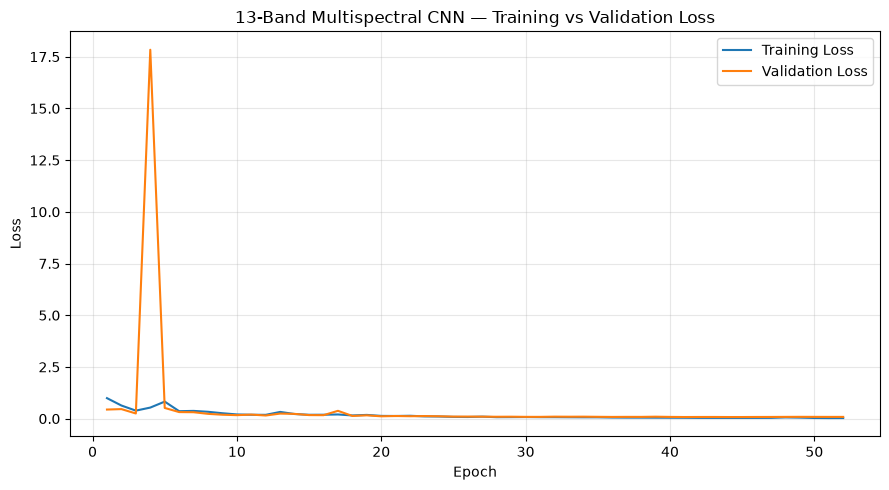

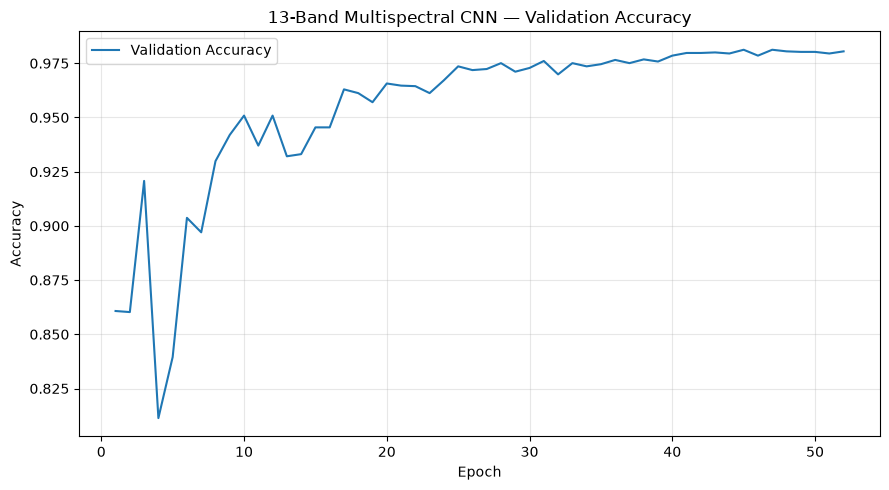

In [11]:
import matplotlib.pyplot as plt


# ============================================================
# 1. RGB — LOSS CURVE
# ============================================================

rgb_epochs = range(1, len(rgb_history["train_loss"]) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    rgb_epochs,
    rgb_history["train_loss"],
    label="Training Loss"
)

plt.plot(
    rgb_epochs,
    rgb_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RGB CNN — Training vs Validation Loss")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 2. RGB — VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    rgb_epochs,
    rgb_history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RGB CNN — Validation Accuracy")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 3. MULTISPECTRAL — LOSS CURVE
# ============================================================

ms_epochs = range(1, len(ms_history["train_loss"]) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    ms_epochs,
    ms_history["train_loss"],
    label="Training Loss"
)

plt.plot(
    ms_epochs,
    ms_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("13-Band Multispectral CNN — Training vs Validation Loss")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 4. MULTISPECTRAL — VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    ms_epochs,
    ms_history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("13-Band Multispectral CNN — Validation Accuracy")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

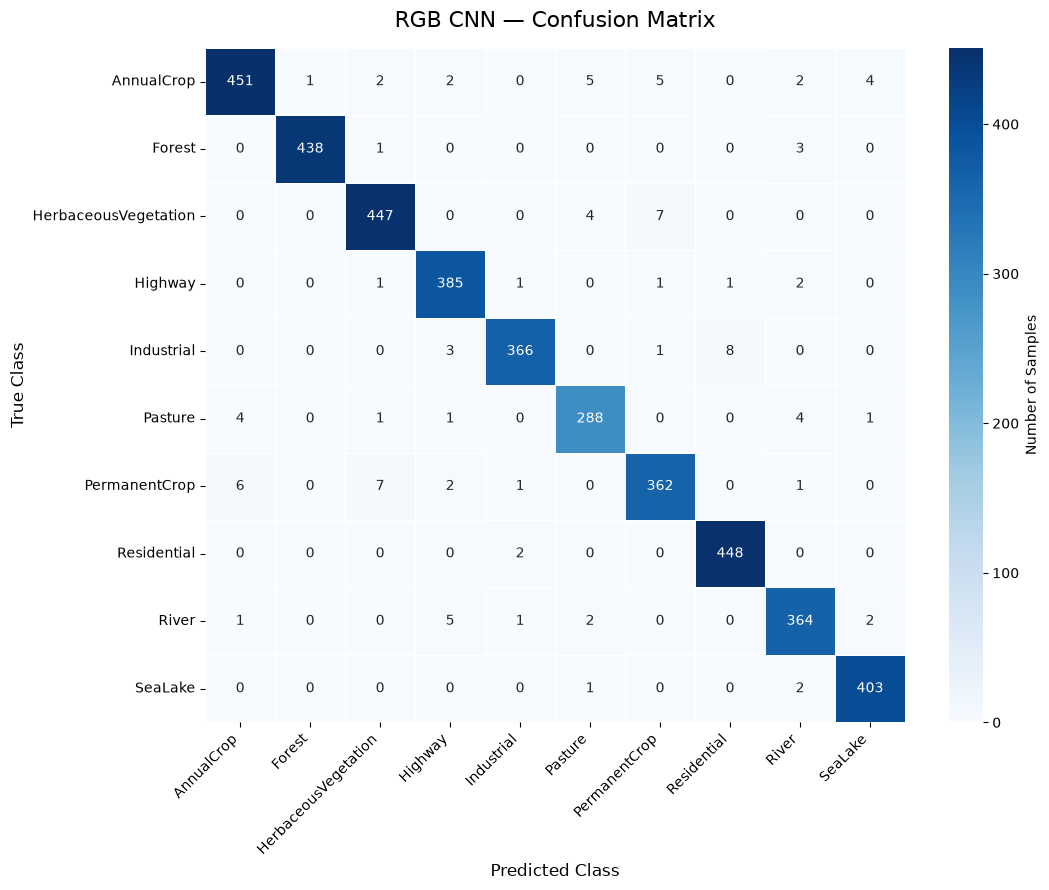

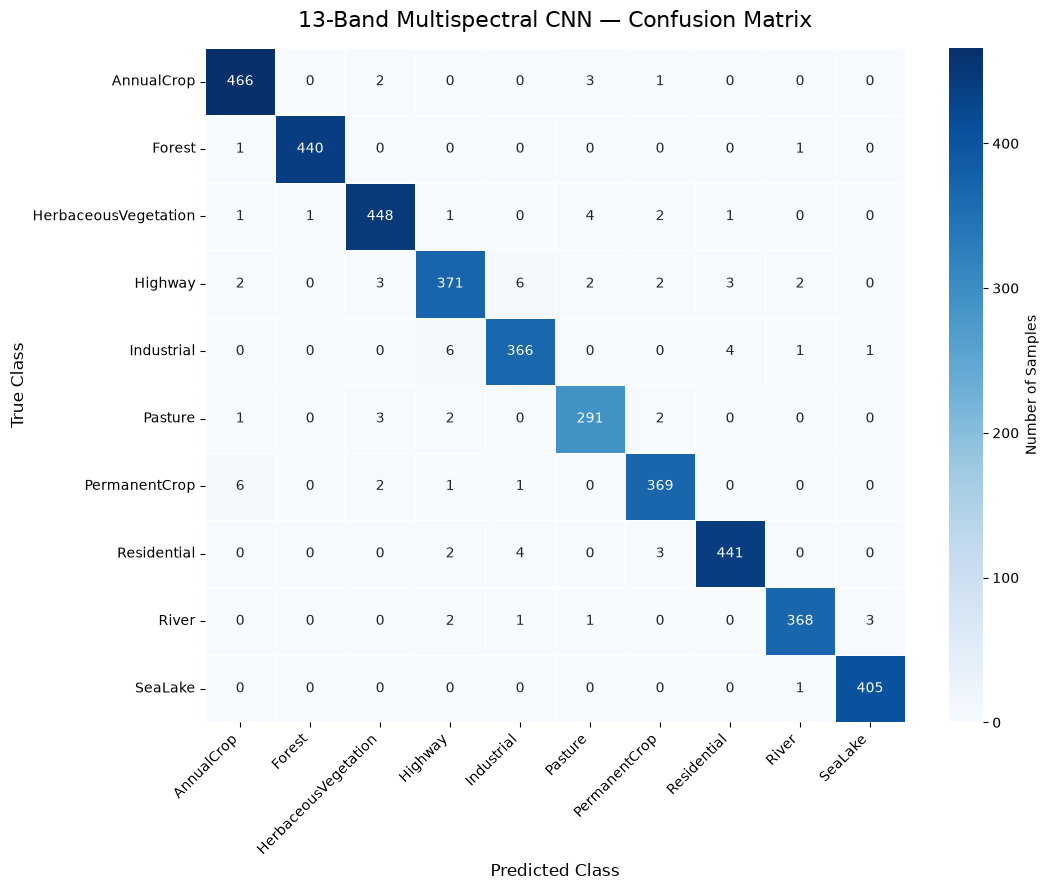

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


# ============================================================
# RGB CONFUSION MATRIX
# ============================================================

rgb_cm = confusion_matrix(
    rgb_true,
    rgb_pred
)

plt.figure(figsize=(11, 9))

sns.heatmap(
    rgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Number of Samples"
    }
)

plt.title(
    "RGB CNN — Confusion Matrix",
    fontsize=16,
    pad=15
)

plt.xlabel(
    "Predicted Class",
    fontsize=12
)

plt.ylabel(
    "True Class",
    fontsize=12
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()


# ============================================================
# 13-BAND MULTISPECTRAL CONFUSION MATRIX
# ============================================================

ms_cm = confusion_matrix(
    ms_true,
    ms_pred
)

plt.figure(figsize=(11, 9))

sns.heatmap(
    ms_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Number of Samples"
    }
)

plt.title(
    "13-Band Multispectral CNN — Confusion Matrix",
    fontsize=16,
    pad=15
)

plt.xlabel(
    "Predicted Class",
    fontsize=12
)

plt.ylabel(
    "True Class",
    fontsize=12
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()